# Cycle Count of Flash Attention

记录Flash Attention子算子在Rocket+Gemmini+Saturn架构下的运行周期数并可视化，包括各类**调度逻辑**的开销

包括对不同精度（FP16/FP32）Softmax算子的耗时评估

可视化包括：

- 随相关参数变化，耗时的绝对变化、占比变化
- **Roofline Model**

Parameters:
- Sequence Length: 128, 256, 512, 1024, 2048 (tile shape fixed at 128\*256)
- Tile Shape: 8\*8, 16\*16, 32\*32, 64\*64, 128\*128, 128\*64, 256\*256 (seq length fixed at 1k, fp32 softmax only)
- Head Dim: 64

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Forward Inner Calculation Function

统计Flash Attention循环内部计算模块的各个子操作的耗时，仅进行单次分块计算，分块大小即视为序列长度大小

仅统计FP32 Softmax，Head Dimension取64

仅供参考，无太大实际意义

Parameters: different tile shape `BR` `BC`

In [14]:
df_inner_fp32 = pd.read_excel(io="data/single_head_cycles_cnt_fp32.xlsx", sheet_name="Inner", header=0, index_col=0)
df_inner_fp32.drop(axis='index', index="单位：周期数 / Head Dimension取64 / Gemmini采用默认INT8 WS配置 / Saturn VLEN=256", inplace=True)
df_inner_fp32.drop(index="rowmax(S)\n(CPU)", inplace=True)
df_inner_fp32.drop(index="exp(S - m)\n(CPU)", inplace=True)
df_inner_fp32.drop(index="rowsum(P)\n(CPU)", inplace=True)
df_inner_fp32.drop(index="normalization\n(CPU)", inplace=True)
df_inner_fp32.drop(index="softmax(S)\n(RVV)", inplace=True)
df_inner_fp32

,1x5,8x8,16x16,16x64,64x16,64x64,64x128,128x64,128x128,256x256
QK^T,1047.0,1230.0,1358.0,1282.0,1950.0,3895.0,7491.0,6079.0,10940.0,48537.0
PV,624.0,756.0,1009.0,1226.0,1711.0,3787.0,5940.0,6315.0,10590.0,25999.0
rowmax(S)\n(RVV),136.0,806.0,1619.0,2147.0,6385.0,8136.0,10255.0,15878.0,19296.0,52455.0
exp(S - m)\n(RVV),152.0,963.0,2072.0,6133.0,7967.0,24293.0,48477.0,48473.0,96943.0,396106.0
rowsum(P)\n(RVV),161.0,1075.0,2086.0,2289.0,7991.0,8905.0,10237.0,17761.0,20574.0,80068.0
normalization\n(RVV),40.0,381.0,706.0,1367.0,3120.0,3397.0,5070.0,6085.0,9831.0,43167.0


### 绝对周期数随分块大小的变化

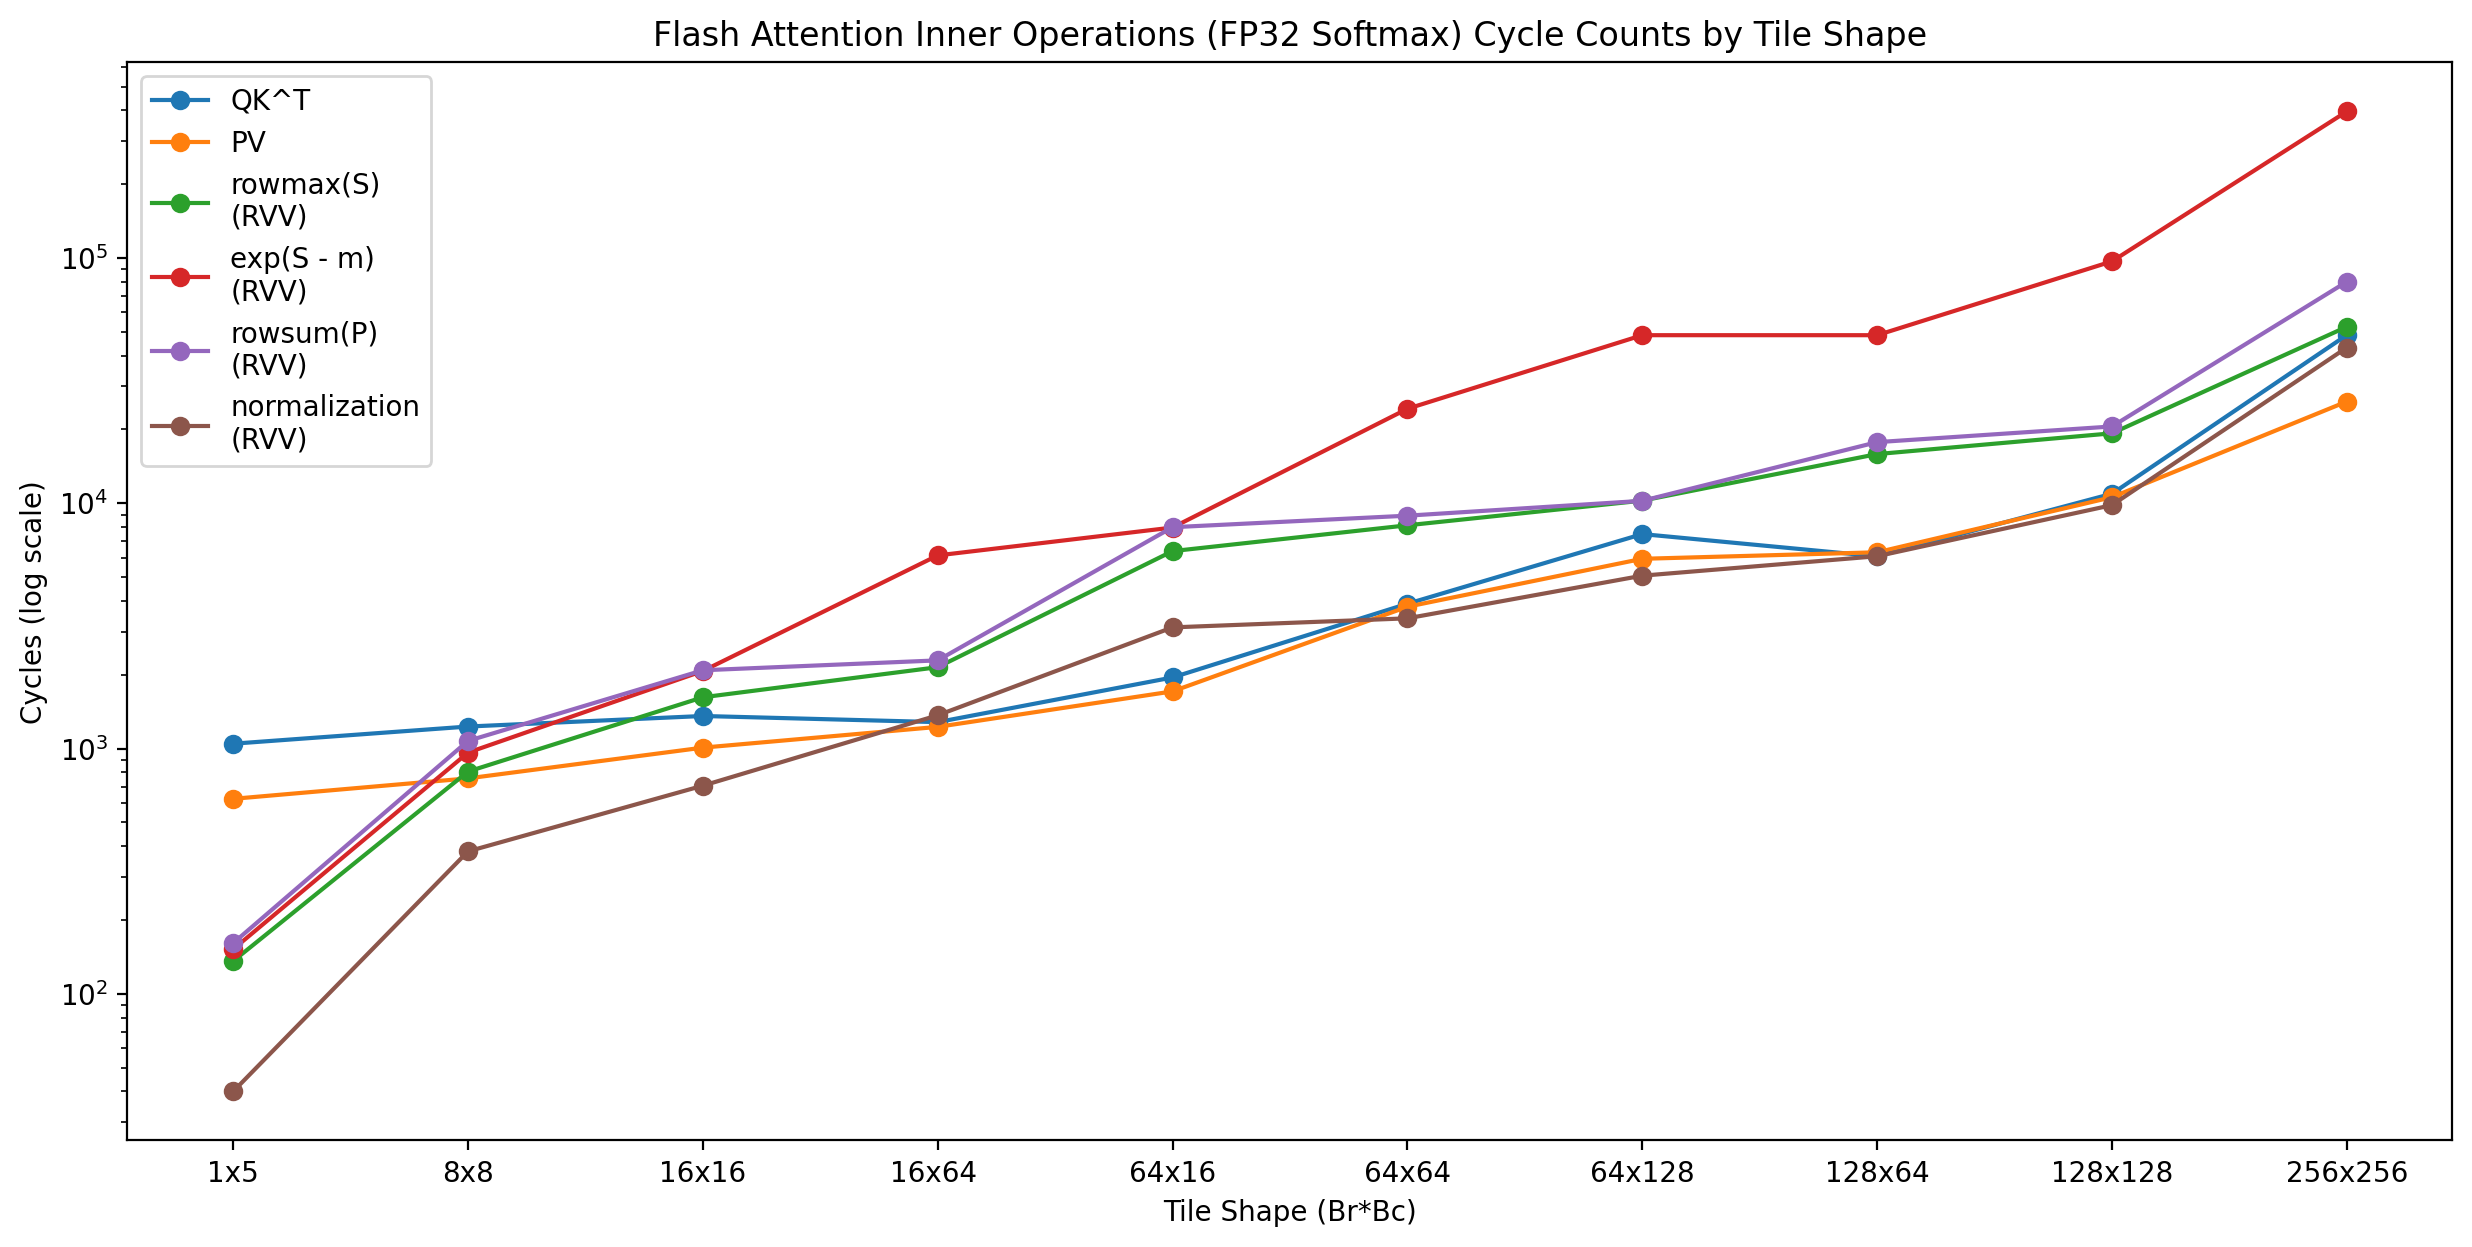

In [15]:
# 分操作可视化周期数
operations = df_inner_fp32.index.tolist()
shapes = df_inner_fp32.columns.tolist()
plt.figure(figsize=(15, 7), dpi=200)
for i, operation in enumerate(operations):
    plt.plot(shapes, df_inner_fp32.loc[operation], marker='o', label=operation)

plt.yscale('log')
plt.xlabel("Tile Shape (Br*Bc)")
plt.ylabel("Cycles (log scale)")
plt.title("Flash Attention Inner Operations (FP32 Softmax) Cycle Counts by Tile Shape")
plt.legend()

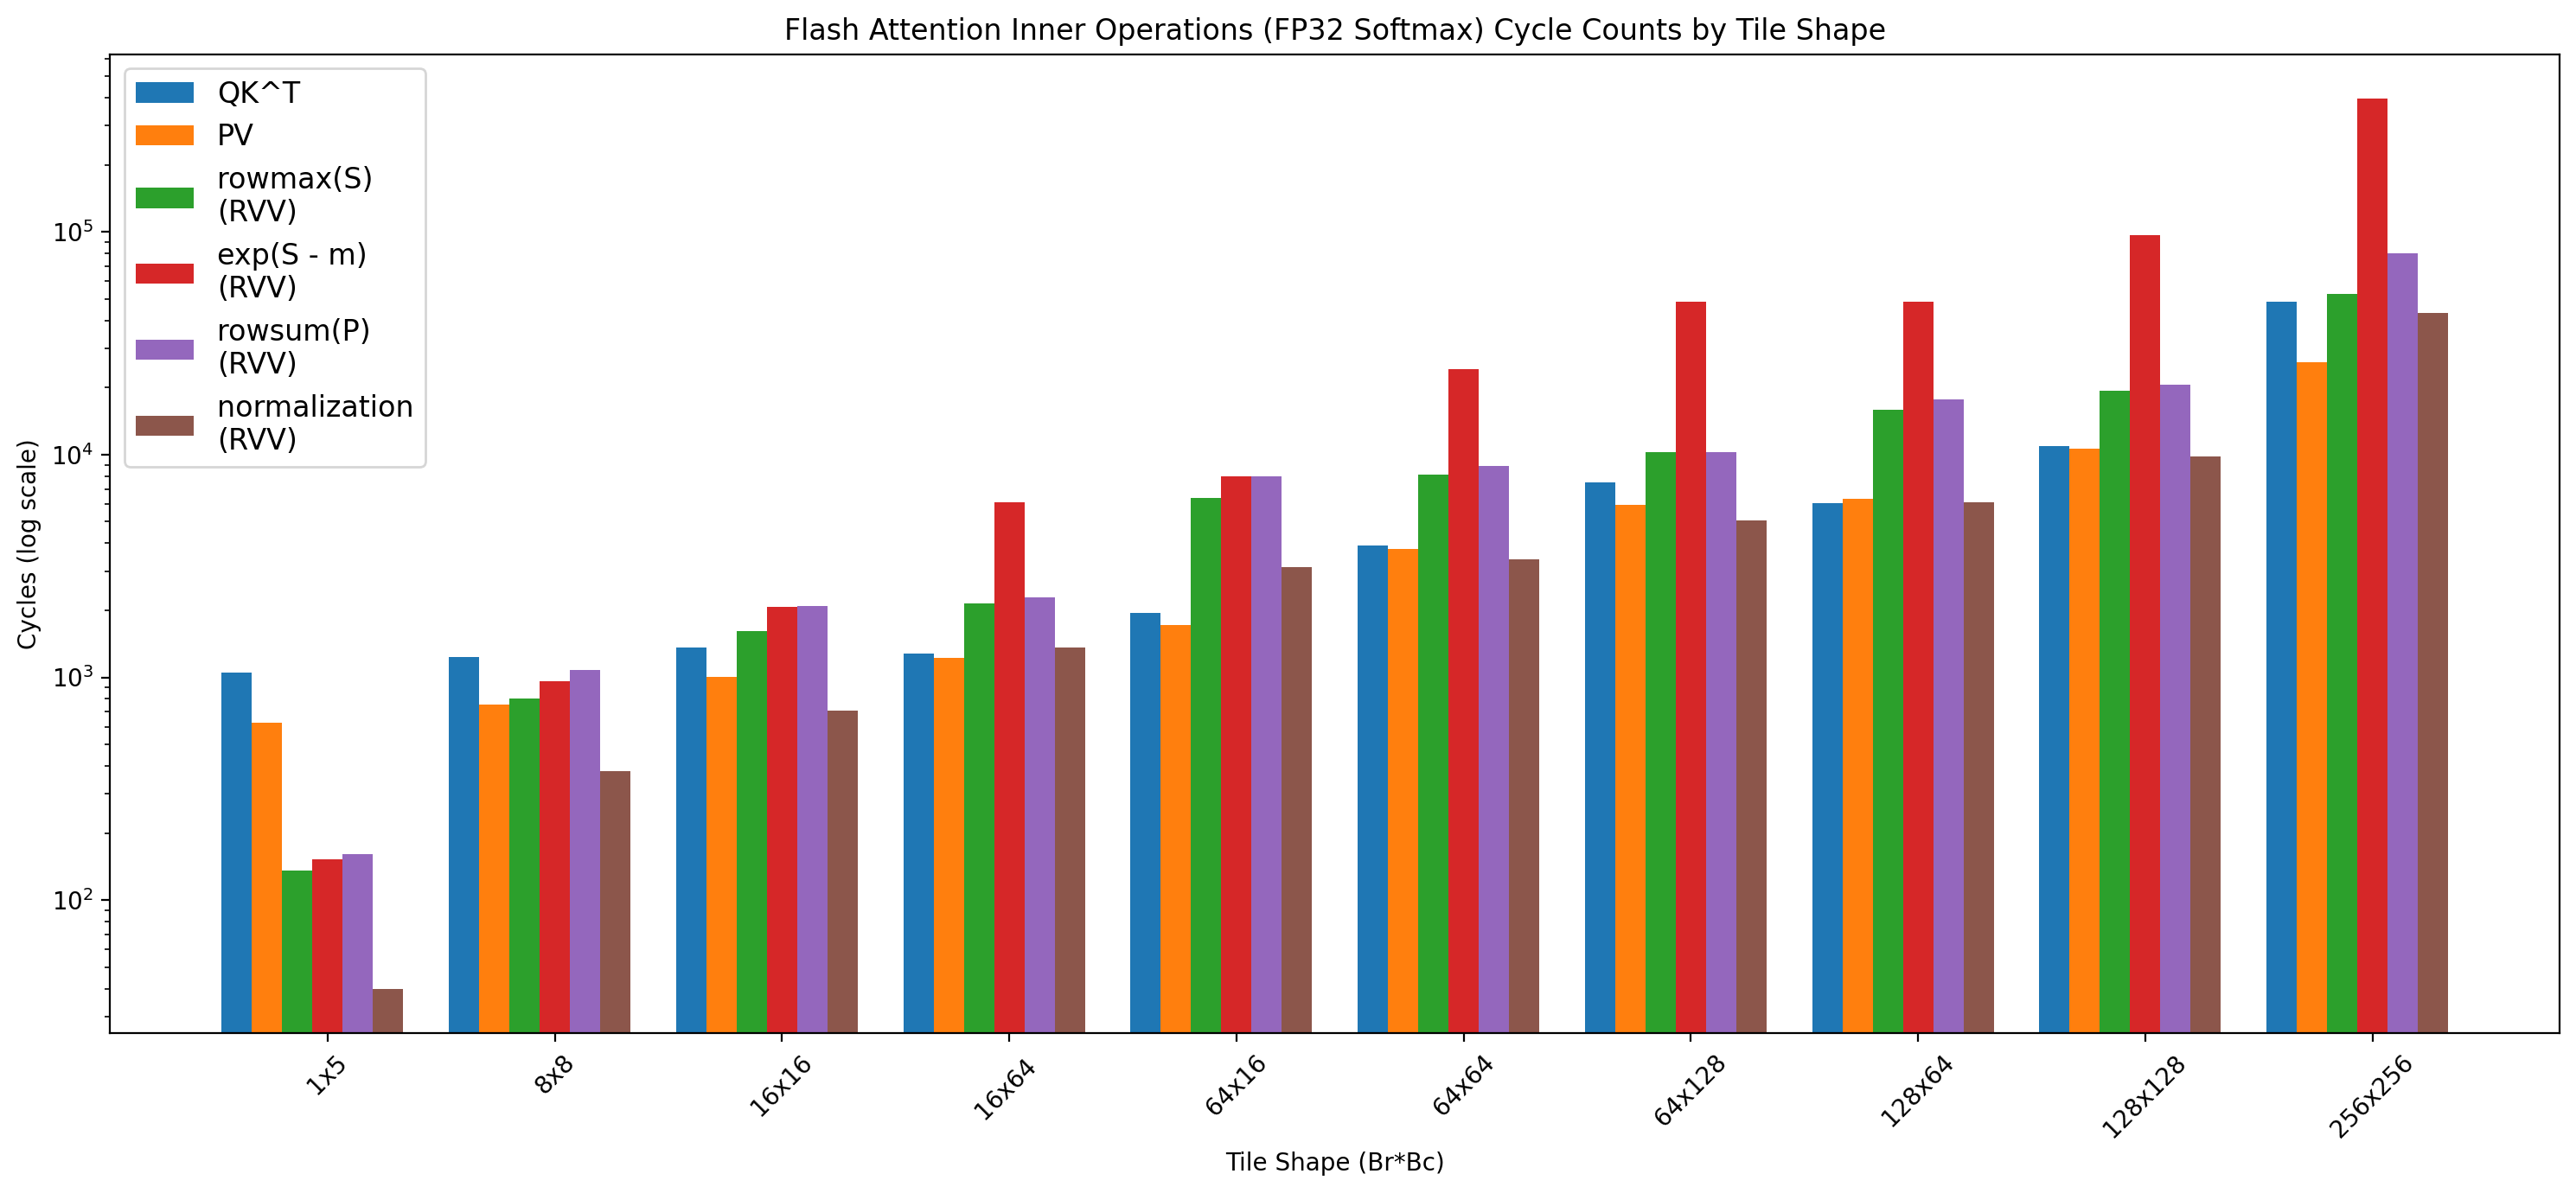

In [16]:
x = np.arange(len(shapes))
width = 0.8 / len(operations)

plt.figure(figsize=(15, 7), dpi=200)
for i, operation in enumerate(operations):
    plt.bar(x + i * width, df_inner_fp32.loc[operation], width, label=operation)

plt.yscale('log')
plt.xlabel("Tile Shape (Br*Bc)")
plt.ylabel("Cycles (log scale)")
plt.title("Flash Attention Inner Operations (FP32 Softmax) Cycle Counts by Tile Shape")
plt.xticks(x + width * len(operations) / 2, shapes, rotation=45)
plt.legend(loc='upper left', fontsize='large')
plt.tight_layout()

### 相对占比随分块大小的变化

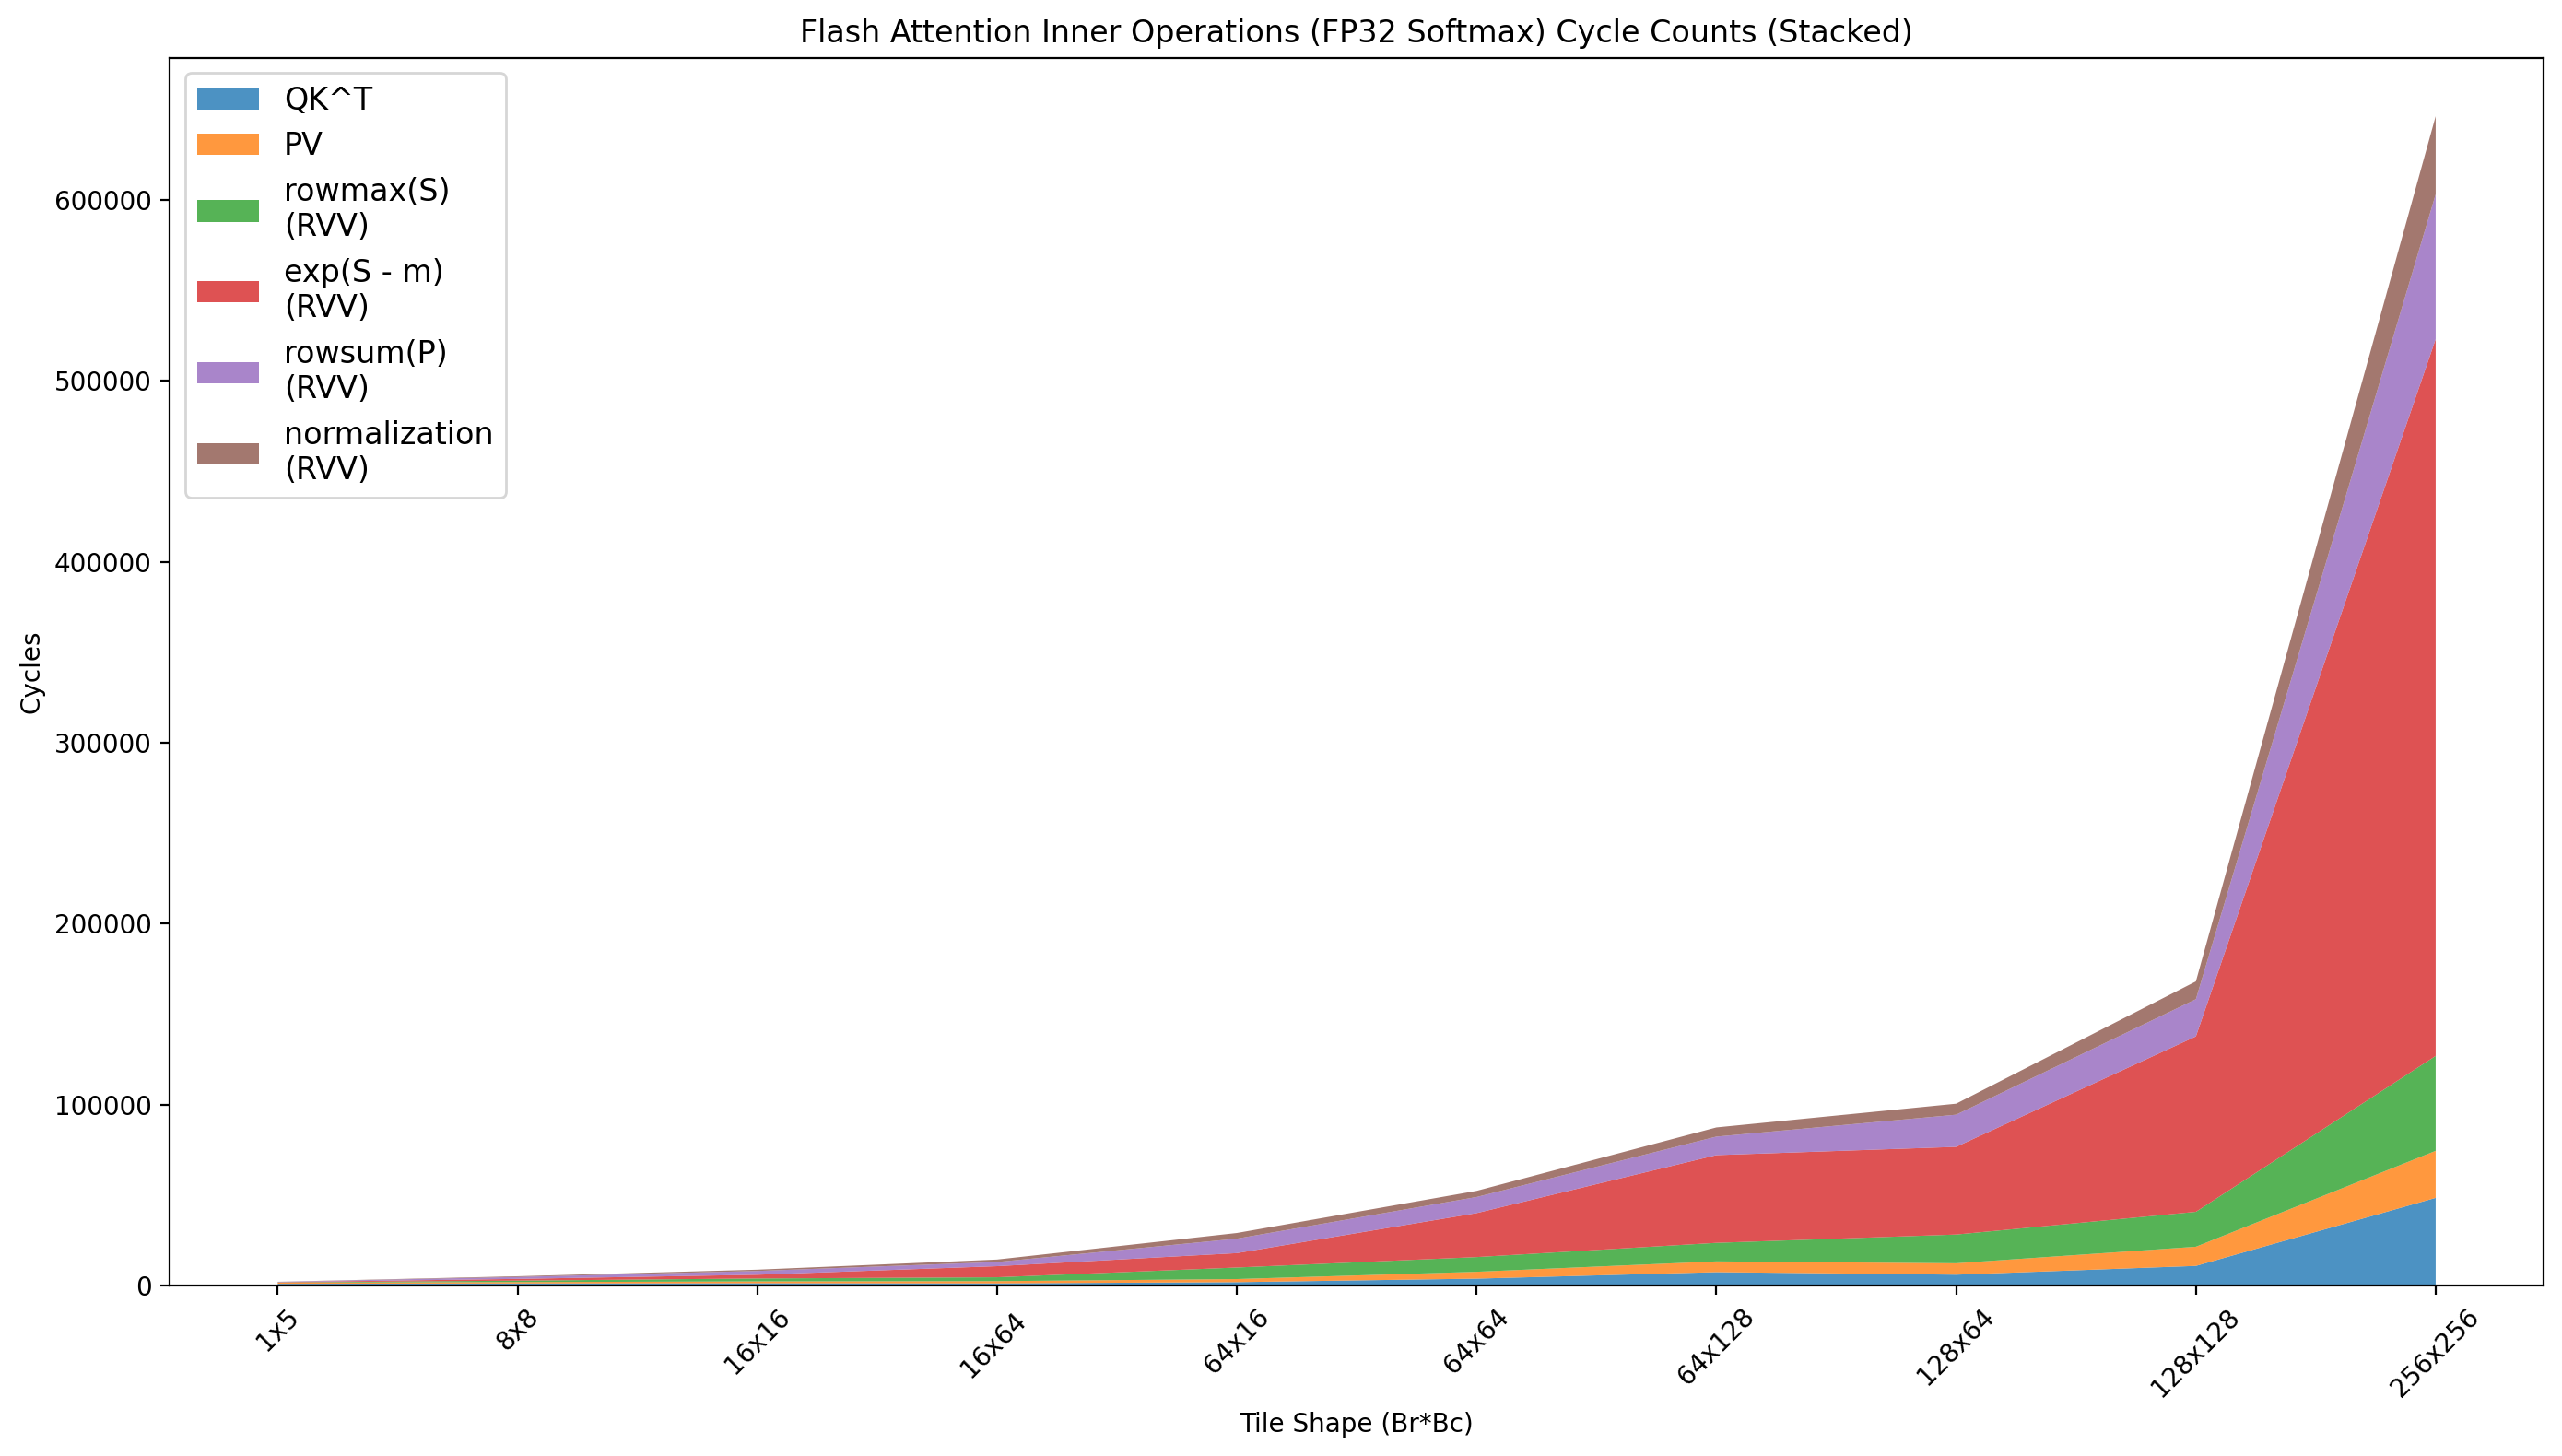

In [17]:
# 分操作可视化周期数 - 堆叠面积图
operations = df_inner_fp32.index.tolist()
shapes = df_inner_fp32.columns.tolist()

plt.figure(figsize=(14, 8), dpi=200)
plt.stackplot(range(len(shapes)), [df_inner_fp32.loc[op] for op in operations], 
              labels=operations, alpha=0.8)
plt.xticks(range(len(shapes)), shapes, rotation=45)
plt.xlabel("Tile Shape (Br*Bc)")
plt.ylabel("Cycles")
plt.title("Flash Attention Inner Operations (FP32 Softmax) Cycle Counts (Stacked)")
plt.legend(loc='upper left', fontsize='large')
plt.tight_layout()

## Single Head Function

统计单头Flash Attention在不同Sequence Length，不同Tile Shape，不同Softmax精度下的时长分布

### Cycles per Sequence Length

Tile Shape固定为`128x256`,序列长度由`128`至`2048`，Head Dimension取`64`

In [18]:
df_single_head_per_seq_fp32 = pd.read_excel(io="data/single_head_cycles_cnt_fp32.xlsx", sheet_name="Single Head (per seq length)", header=0, index_col=0)
df_single_head_per_seq_fp32.drop(axis='index', index="单位：周期数 / Head Dimension取64 / Tile Shape固定Br*Bc = 128*256", inplace=True)
df_single_head_per_seq_fp16 = pd.read_excel(io="data/single_head_cycles_cnt_fp16.xlsx", sheet_name="Single Head (per seq length)", header=0, index_col=0)
df_single_head_per_seq_fp16.drop(axis='index', index="单位：周期数 / Head Dimension取64 / Tile Shape固定Br*Bc = 128*256", inplace=True)
df_single_head_per_seq_fp16

,128,256,512,1024,2048
QK^T,15365.0,31182.0,86548.0,303016.0,1085809.0
PV,14005.0,27687.0,82301.0,272396.0,974993.0
softmax(S)\n(including mask & dequant),137659.0,333785.0,1089405.0,4198285.0,14603416.0
output accum & dequat,9745.0,20068.0,68731.0,255323.0,1026586.0
normalization,7743.0,16180.0,34863.0,74464.0,151891.0
initialization & other overheads,50050.0,51425.0,117289.0,316855.0,981156.0
TOTAL,234567.0,480327.0,1479137.0,5420339.0,18823851.0


In [19]:
df_single_head_per_seq_fp32

,128,256,512,1024,2048
QK^T,15322.0,31001.0,86616.0,281932.0,1085706.0
PV,13978.0,27656.0,81909.0,270789.0,972768.0
softmax(S)\n(including mask & dequant),188272.0,473151.0,1553461.0,5576350.0,21010049.0
output accum & dequat,9500.0,19474.0,69392.0,259796.0,1027503.0
normalization,7591.0,16435.0,34579.0,73674.0,151946.0
initialization & other overheads,50761.0,51256.0,117603.0,315820.0,982696.0
TOTAL,285424.0,618973.0,1943560.0,6778361.0,25230668.0


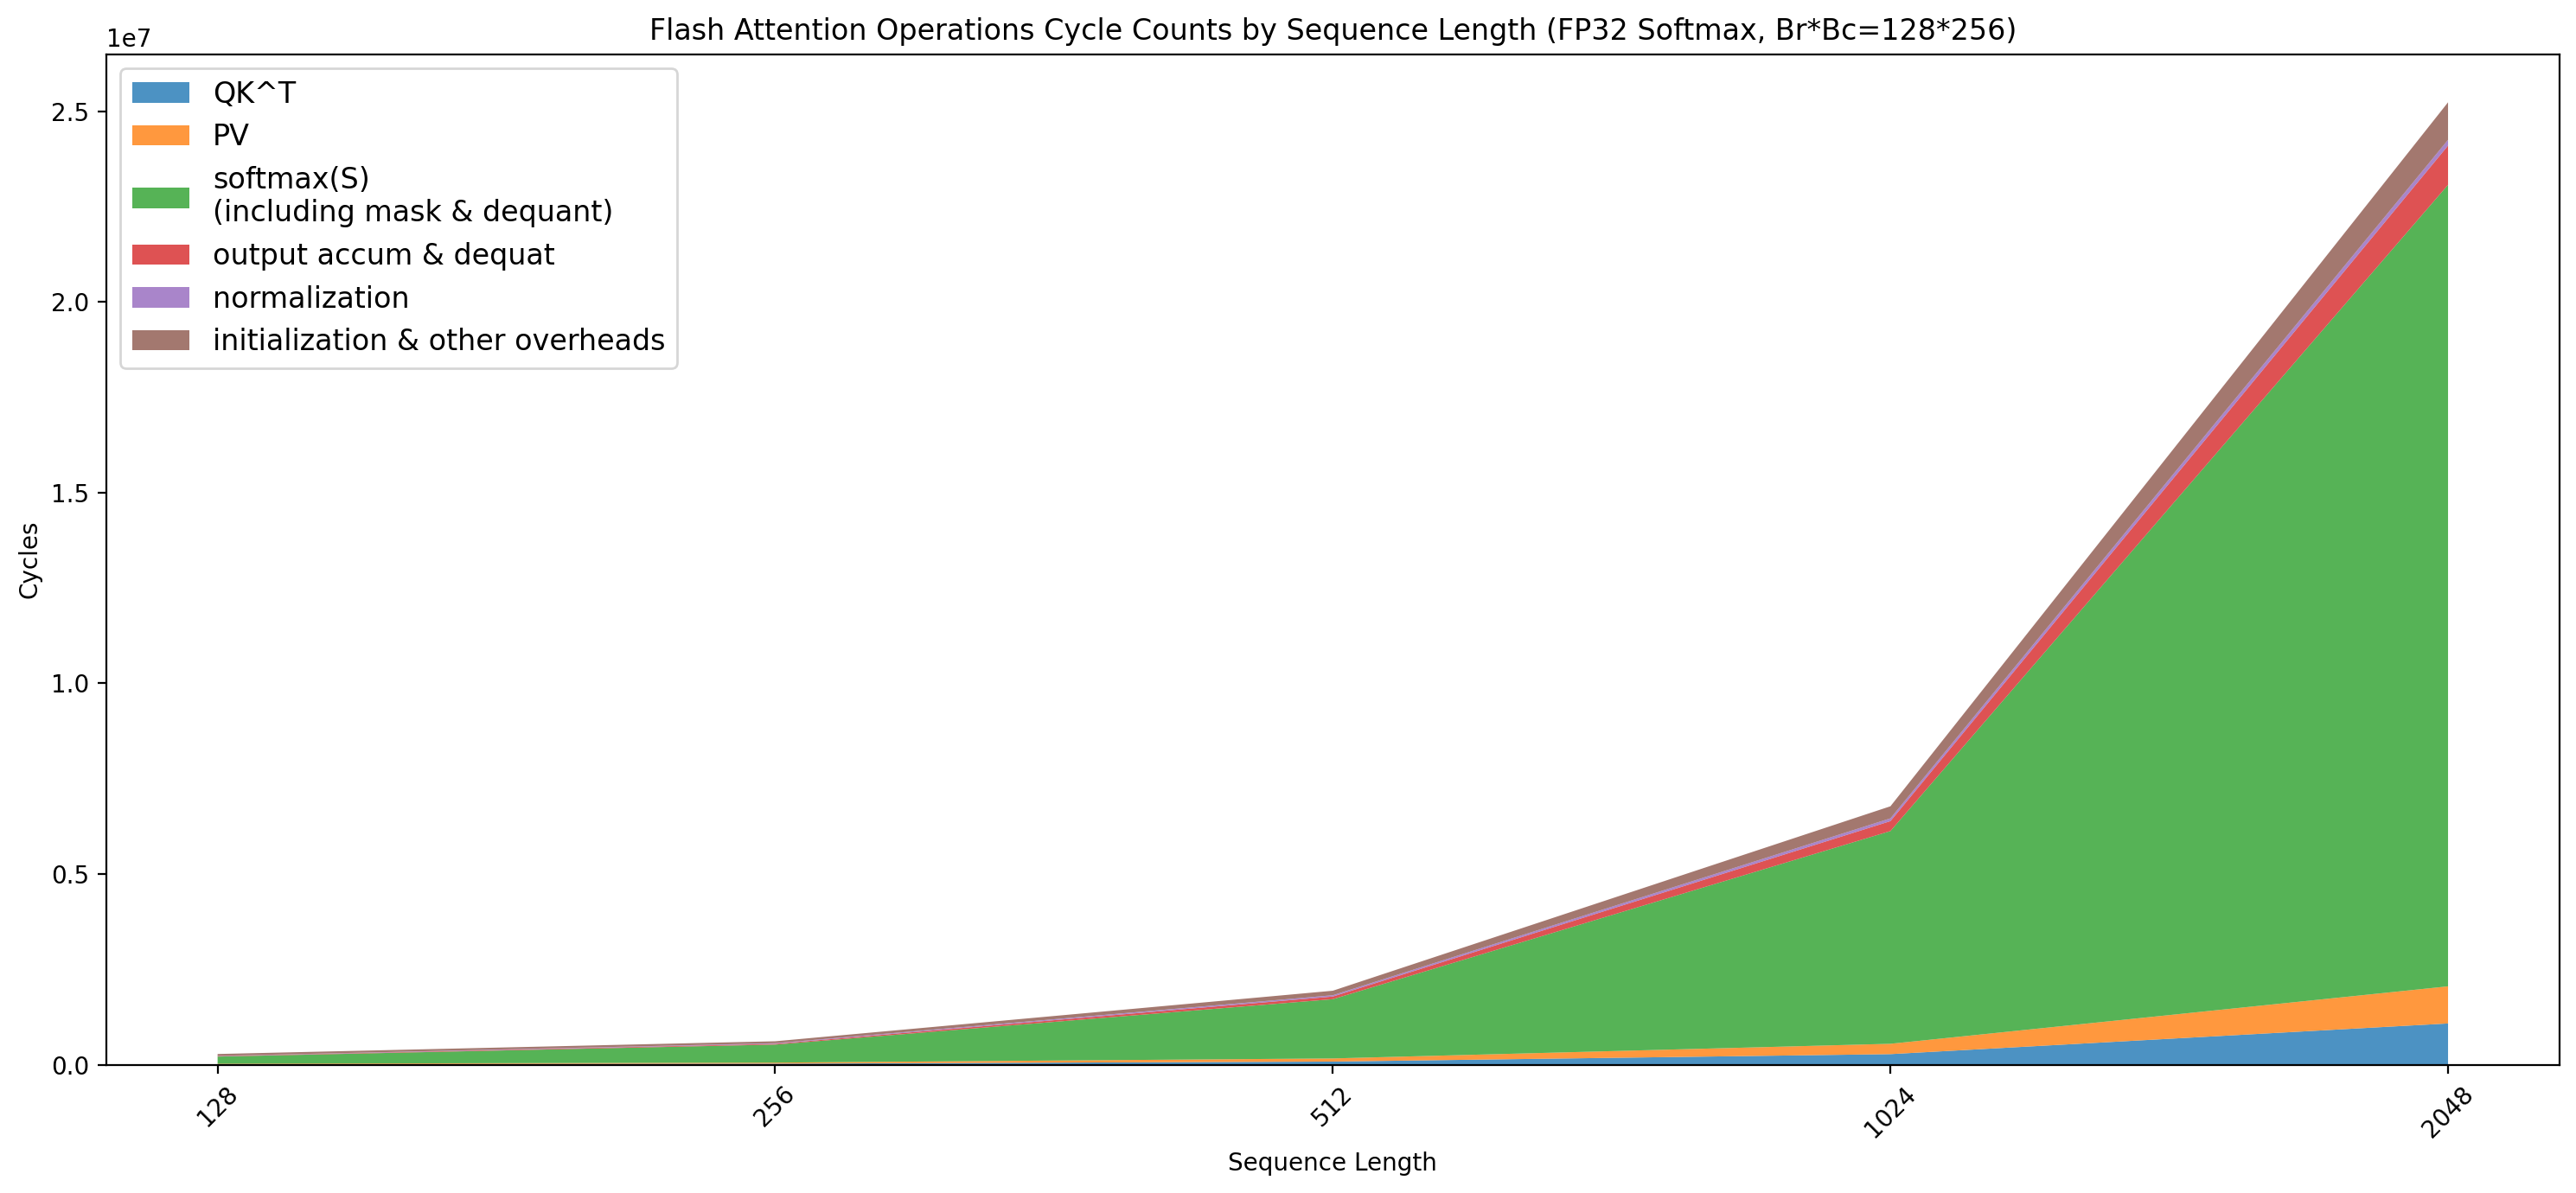

In [20]:
df_withoutTotal_fp32 = df_single_head_per_seq_fp32.drop(index="TOTAL", inplace=False)
operations = df_withoutTotal_fp32.index.tolist()
sequence_length = df_withoutTotal_fp32.columns.tolist()

plt.figure(figsize=(15, 7), dpi=200)
plt.stackplot(range(len(sequence_length)), [df_withoutTotal_fp32.loc[op] for op in operations], labels=operations, alpha=0.8)
plt.xticks(range(len(sequence_length)), sequence_length, rotation=45)
plt.xlabel("Sequence Length")
plt.ylabel("Cycles")
plt.title("Flash Attention Operations Cycle Counts by Sequence Length (FP32 Softmax, Br*Bc=128*256)")
plt.legend(loc='upper left', fontsize='large')
plt.tight_layout()

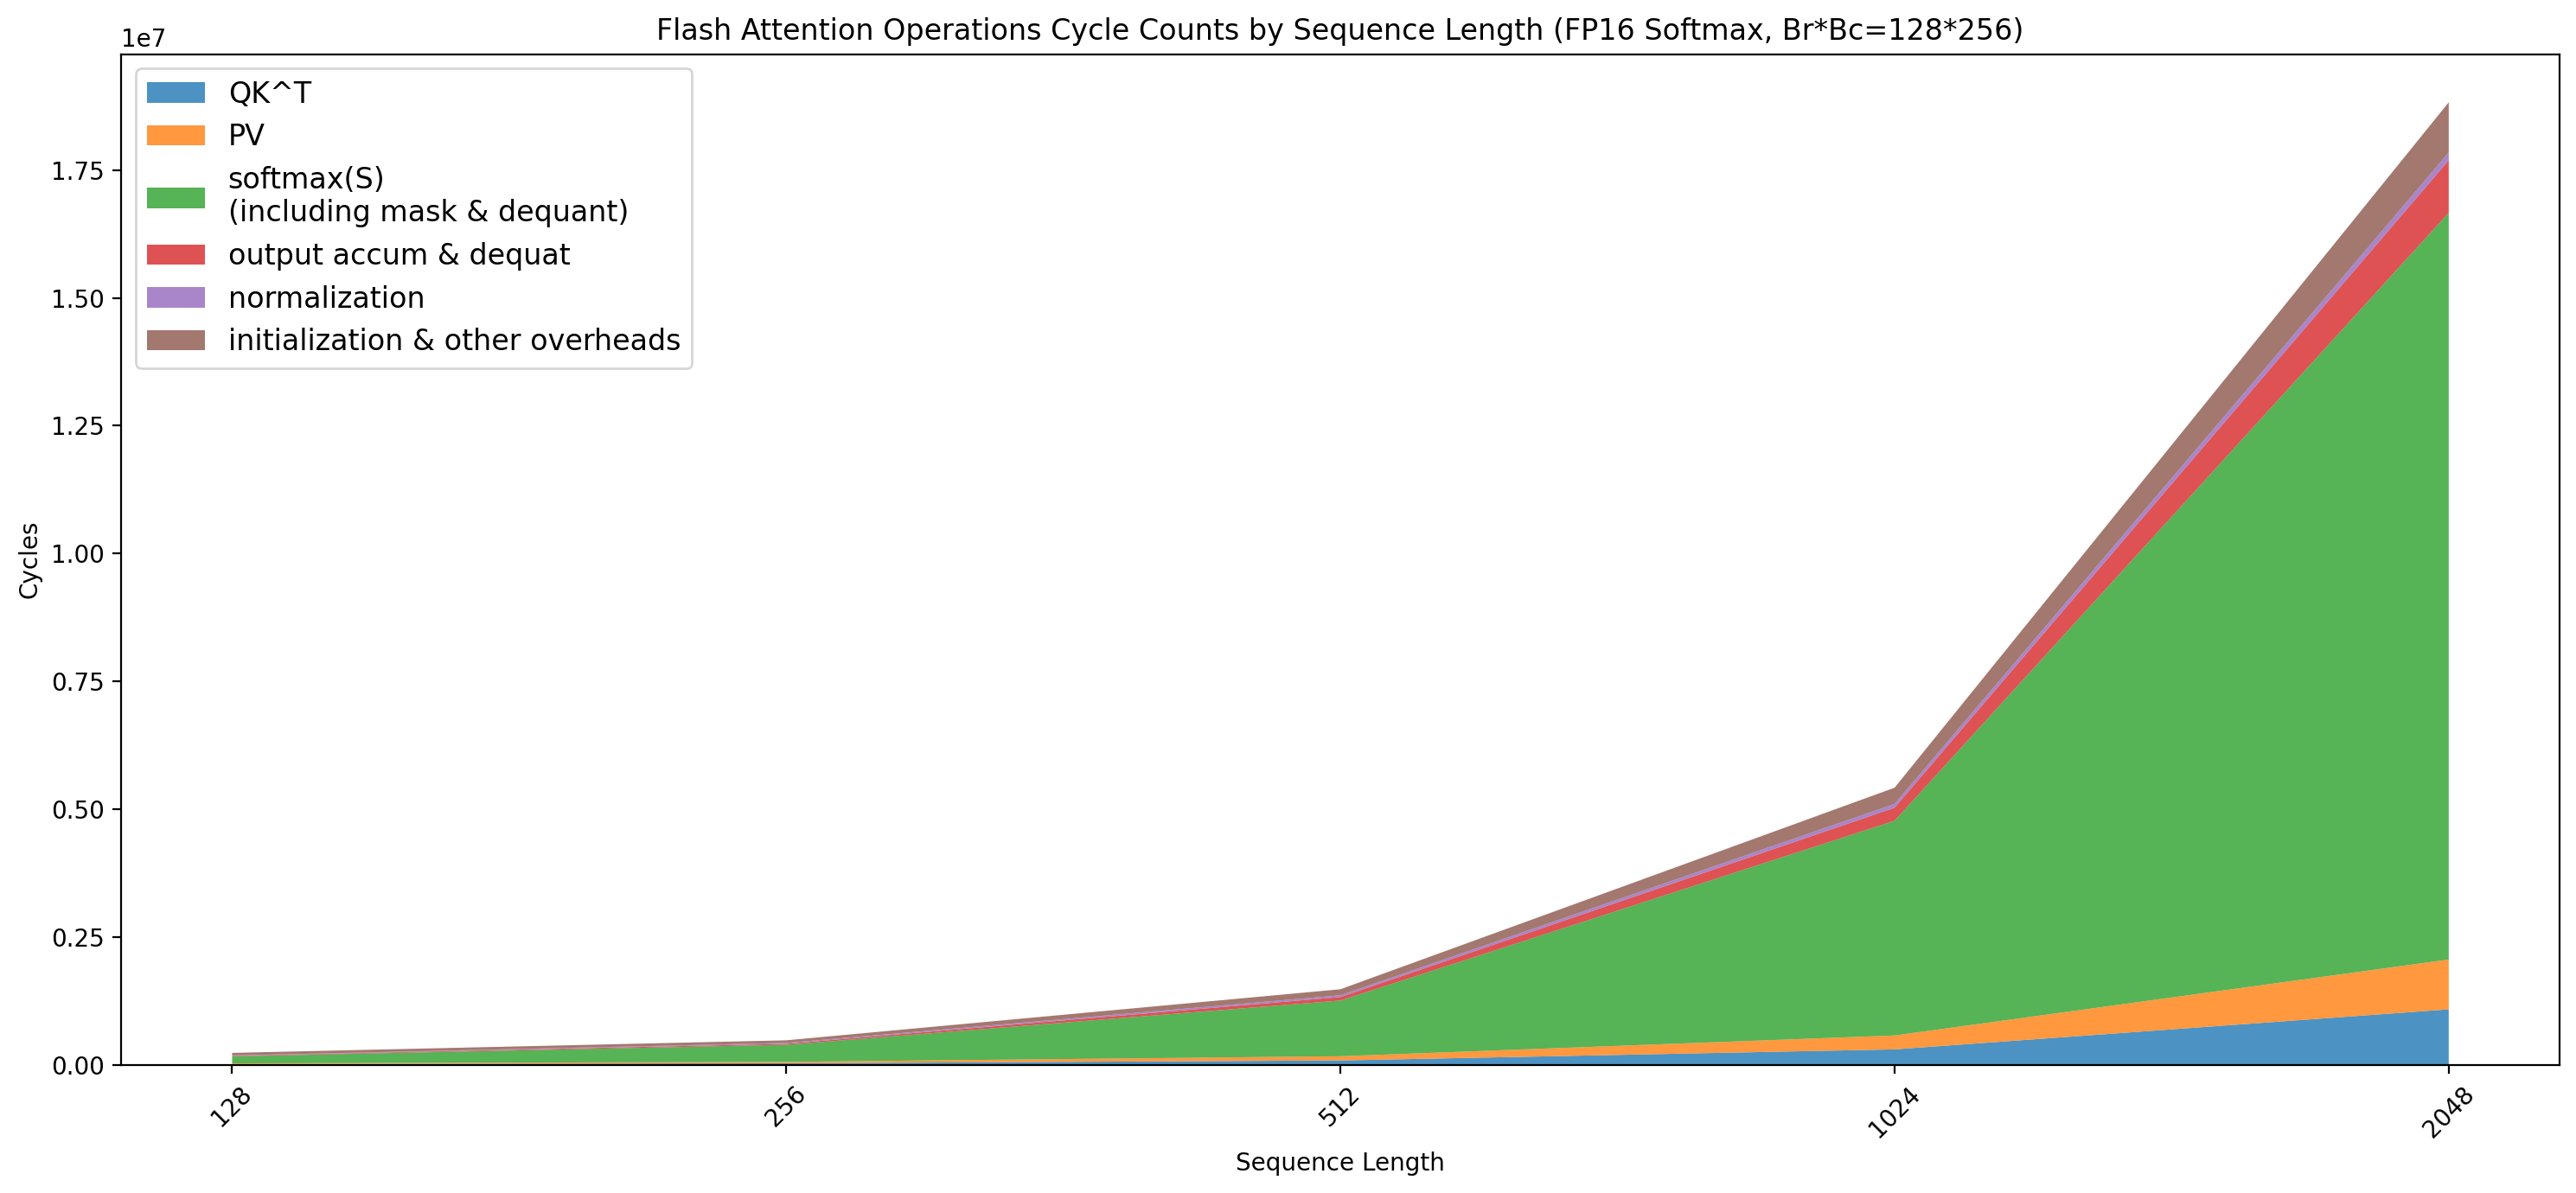

In [21]:
df_withoutTotal_fp16 = df_single_head_per_seq_fp16.drop(index="TOTAL", inplace=False)
operations = df_withoutTotal_fp16.index.tolist()
sequence_length = df_withoutTotal_fp16.columns.tolist()

plt.figure(figsize=(15, 7), dpi=200)
plt.stackplot(range(len(sequence_length)), [df_withoutTotal_fp16.loc[op] for op in operations], labels=operations, alpha=0.8)
plt.xticks(range(len(sequence_length)), sequence_length, rotation=45)
plt.xlabel("Sequence Length")
plt.ylabel("Cycles")
plt.title("Flash Attention Operations Cycle Counts by Sequence Length (FP16 Softmax, Br*Bc=128*256)")
plt.legend(loc='upper left', fontsize='large')
plt.tight_layout()

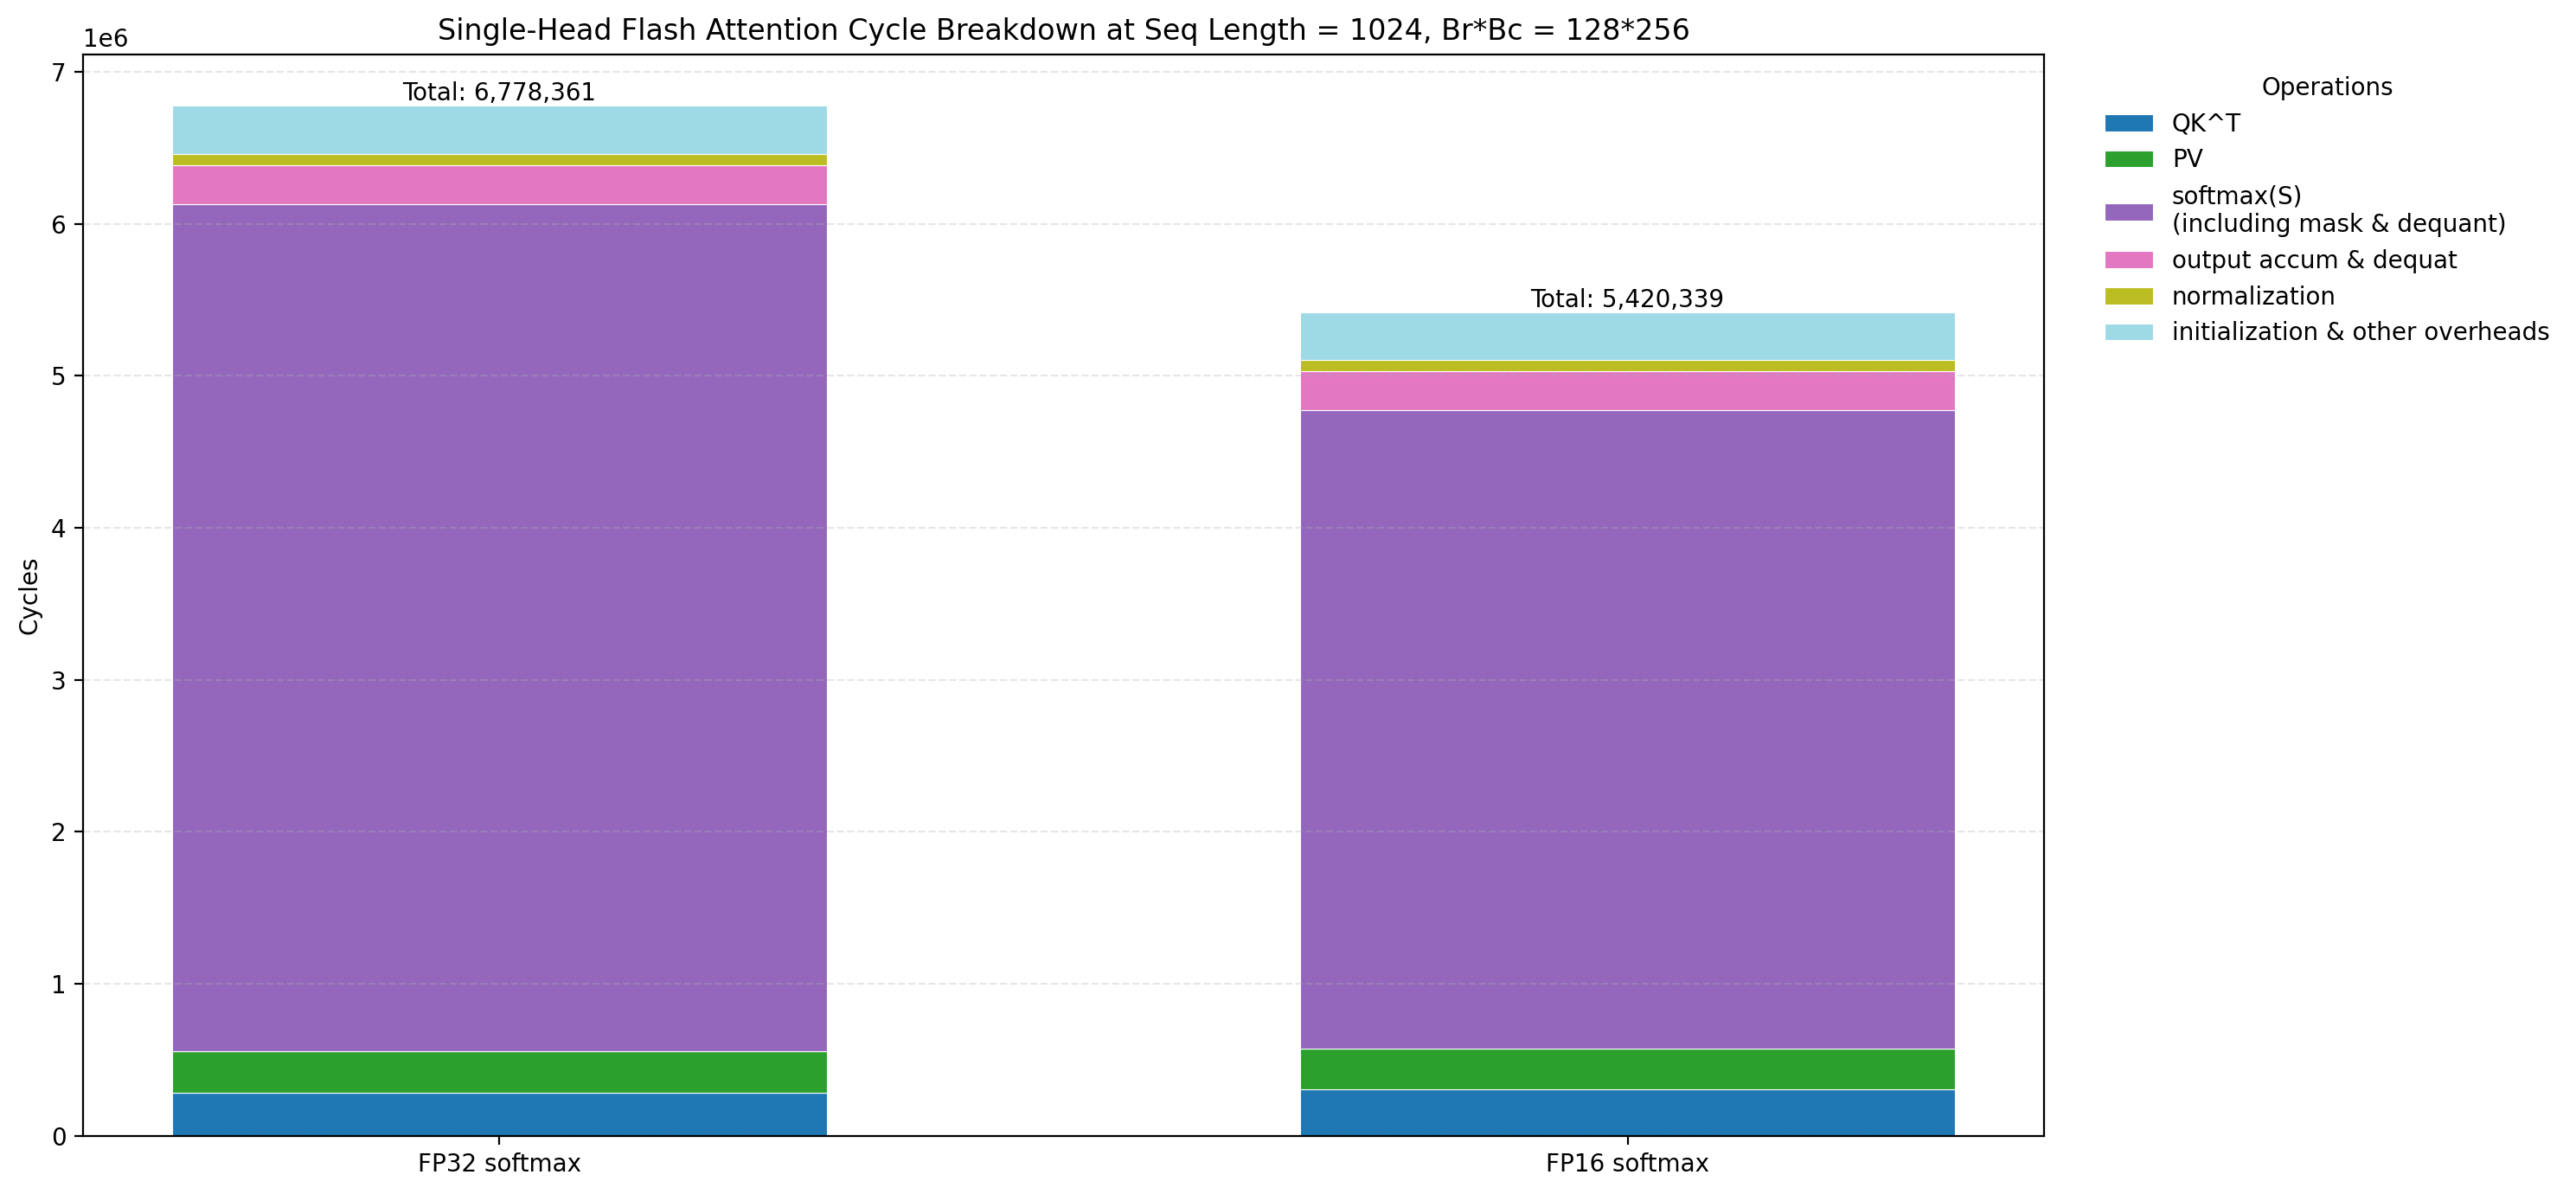

,FP32 cycles,FP16 cycles,Delta (FP16-FP32),Change% (vs FP32)
QK^T,281932.0,303016.0,21084.0,7.478399
PV,270789.0,272396.0,1607.0,0.593451
softmax(S)\n(including mask & dequant),5576350.0,4198285.0,-1378065.0,-24.712670
output accum & dequat,259796.0,255323.0,-4473.0,-1.721736
normalization,73674.0,74464.0,790.0,1.072291
initialization & other overheads,315820.0,316855.0,1035.0,0.327718
TOTAL,6778361.0,5420339.0,-1358022.0,-20.034666


In [22]:
# Seq Length = 1k 时，FP32 softmax 与 FP16 softmax 的分操作耗时对比（堆叠双柱）
def _find_seq_col(df, candidates=(1024, "1024", "1k", "1K", "seq1024")):
    for c in candidates:
        if c in df.columns:
            return c

    normalized_cols = {str(c).strip().lower().replace(" ", ""): c for c in df.columns}
    for c in candidates:
        key = str(c).strip().lower().replace(" ", "")
        if key in normalized_cols:
            return normalized_cols[key]

    raise KeyError(f"无法在列中找到 1k/1024，对应可用列为: {list(df.columns)}")

seq_col_fp32 = _find_seq_col(df_single_head_per_seq_fp32)
seq_col_fp16 = _find_seq_col(df_single_head_per_seq_fp16)

ops_fp32_order = df_single_head_per_seq_fp32.index.tolist()
ops_common = [
    op for op in ops_fp32_order
    if op != "TOTAL" and op in df_single_head_per_seq_fp16.index
]

if len(ops_common) == 0:
    raise ValueError("FP32 与 FP16 表中没有可对齐的操作项")

cycles_fp32 = df_single_head_per_seq_fp32.loc[ops_common, seq_col_fp32].astype(float)
cycles_fp16 = df_single_head_per_seq_fp16.loc[ops_common, seq_col_fp16].astype(float)

fig, ax = plt.subplots(figsize=(15, 7), dpi=200)
x = [0, 1]
width = 0.58
bottom_fp32 = 0.0
bottom_fp16 = 0.0
colors = plt.get_cmap("tab20")(np.linspace(0, 1, len(ops_common)))

for op, color in zip(ops_common, colors):
    v32 = float(cycles_fp32.loc[op])
    v16 = float(cycles_fp16.loc[op])

    ax.bar(x[0], v32, width=width, bottom=bottom_fp32, color=color, edgecolor="white", linewidth=0.4, label=op)
    ax.bar(x[1], v16, width=width, bottom=bottom_fp16, color=color, edgecolor="white", linewidth=0.4)

    bottom_fp32 += v32
    bottom_fp16 += v16

ax.set_xticks(x, ["FP32 softmax", "FP16 softmax"])
ax.set_ylabel("Cycles")
ax.set_title("Single-Head Flash Attention Cycle Breakdown at Seq Length = 1024, Br*Bc = 128*256")
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.legend(title="Operations", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)

ax.text(x[0], bottom_fp32, f"Total: {bottom_fp32:,.0f}", ha="center", va="bottom", fontsize=10)
ax.text(x[1], bottom_fp16, f"Total: {bottom_fp16:,.0f}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

compare_df = pd.DataFrame({
    "FP32 cycles": cycles_fp32,
    "FP16 cycles": cycles_fp16,
})
compare_df["Delta (FP16-FP32)"] = compare_df["FP16 cycles"] - compare_df["FP32 cycles"]
compare_df["Change% (vs FP32)"] = np.where(
    compare_df["FP32 cycles"] != 0,
    compare_df["Delta (FP16-FP32)"] / compare_df["FP32 cycles"] * 100.0,
    np.nan,
 )

total_fp32 = compare_df["FP32 cycles"].sum()
total_fp16 = compare_df["FP16 cycles"].sum()
total_delta = total_fp16 - total_fp32
total_pct = (total_delta / total_fp32 * 100.0) if total_fp32 != 0 else np.nan

compare_df.loc["TOTAL"] = [total_fp32, total_fp16, total_delta, total_pct]

display(compare_df.round({
    "FP32 cycles": 2,
    "FP16 cycles": 2,
    "Delta(FP16-FP32)": 2,
    "Change% (vs_FP32)": 4,
}))

### Cycles per Tile Shape

序列长度固定为1k，Head Dimension取64，探索不同分块大小对耗时的影响

仅考虑FP32 Softmax，FP16同理

In [23]:
df_single_head_per_tile_fp32 = pd.read_excel(io="data/single_head_cycles_cnt_fp32.xlsx", sheet_name="Single Head (per tile shape)", header=0, index_col=0)
df_single_head_per_tile_fp32.drop(axis='index', index="单位：周期数 / Head Dimension取64 / Sequence Length固定1k", inplace=True)
df_single_head_per_tile_fp32.drop(labels = "64x512", axis="columns", inplace=True)
df_single_head_per_tile_fp32.drop(labels = "256x512", axis="columns", inplace=True)
df_single_head_per_tile_fp32

,8x8,16x16,32x32,64x64,64x128,64x256,128x128,128x256,256x128,256x256
QK^T,5668132.0,1720108.0,746789.0,401124.0,414386.0,334863.0,328928.0,309936.0,361718.0,331672.0
PV,5314500.0,1687241.0,739922.0,375532.0,313557.0,296775.0,298817.0,273215.0,251611.0,225351.0
softmax(S)\n(including mask & dequant),32312904.0,17637716.0,11004845.0,8053955.0,7084765.0,6028805.0,6643962.0,6051401.0,7729407.0,6220168.0
output accum & dequat,9599684.0,4900786.0,2397549.0,1118502.0,573192.0,297659.0,529537.0,290163.0,578954.0,353162.0
normalization,61086.0,60219.0,61570.0,62713.0,65572.0,67500.0,70059.0,75368.0,79416.0,81501.0
initialization & other overheads,14650919.0,7012784.0,3584122.0,2045089.0,1268732.0,845698.0,1397779.0,876052.0,1560533.0,1041572.0
TOTAL,67607225.0,33018854.0,18534787.0,12056915.0,9720204.0,7871280.0,9269082.0,7876135.0,10561639.0,8253426.0


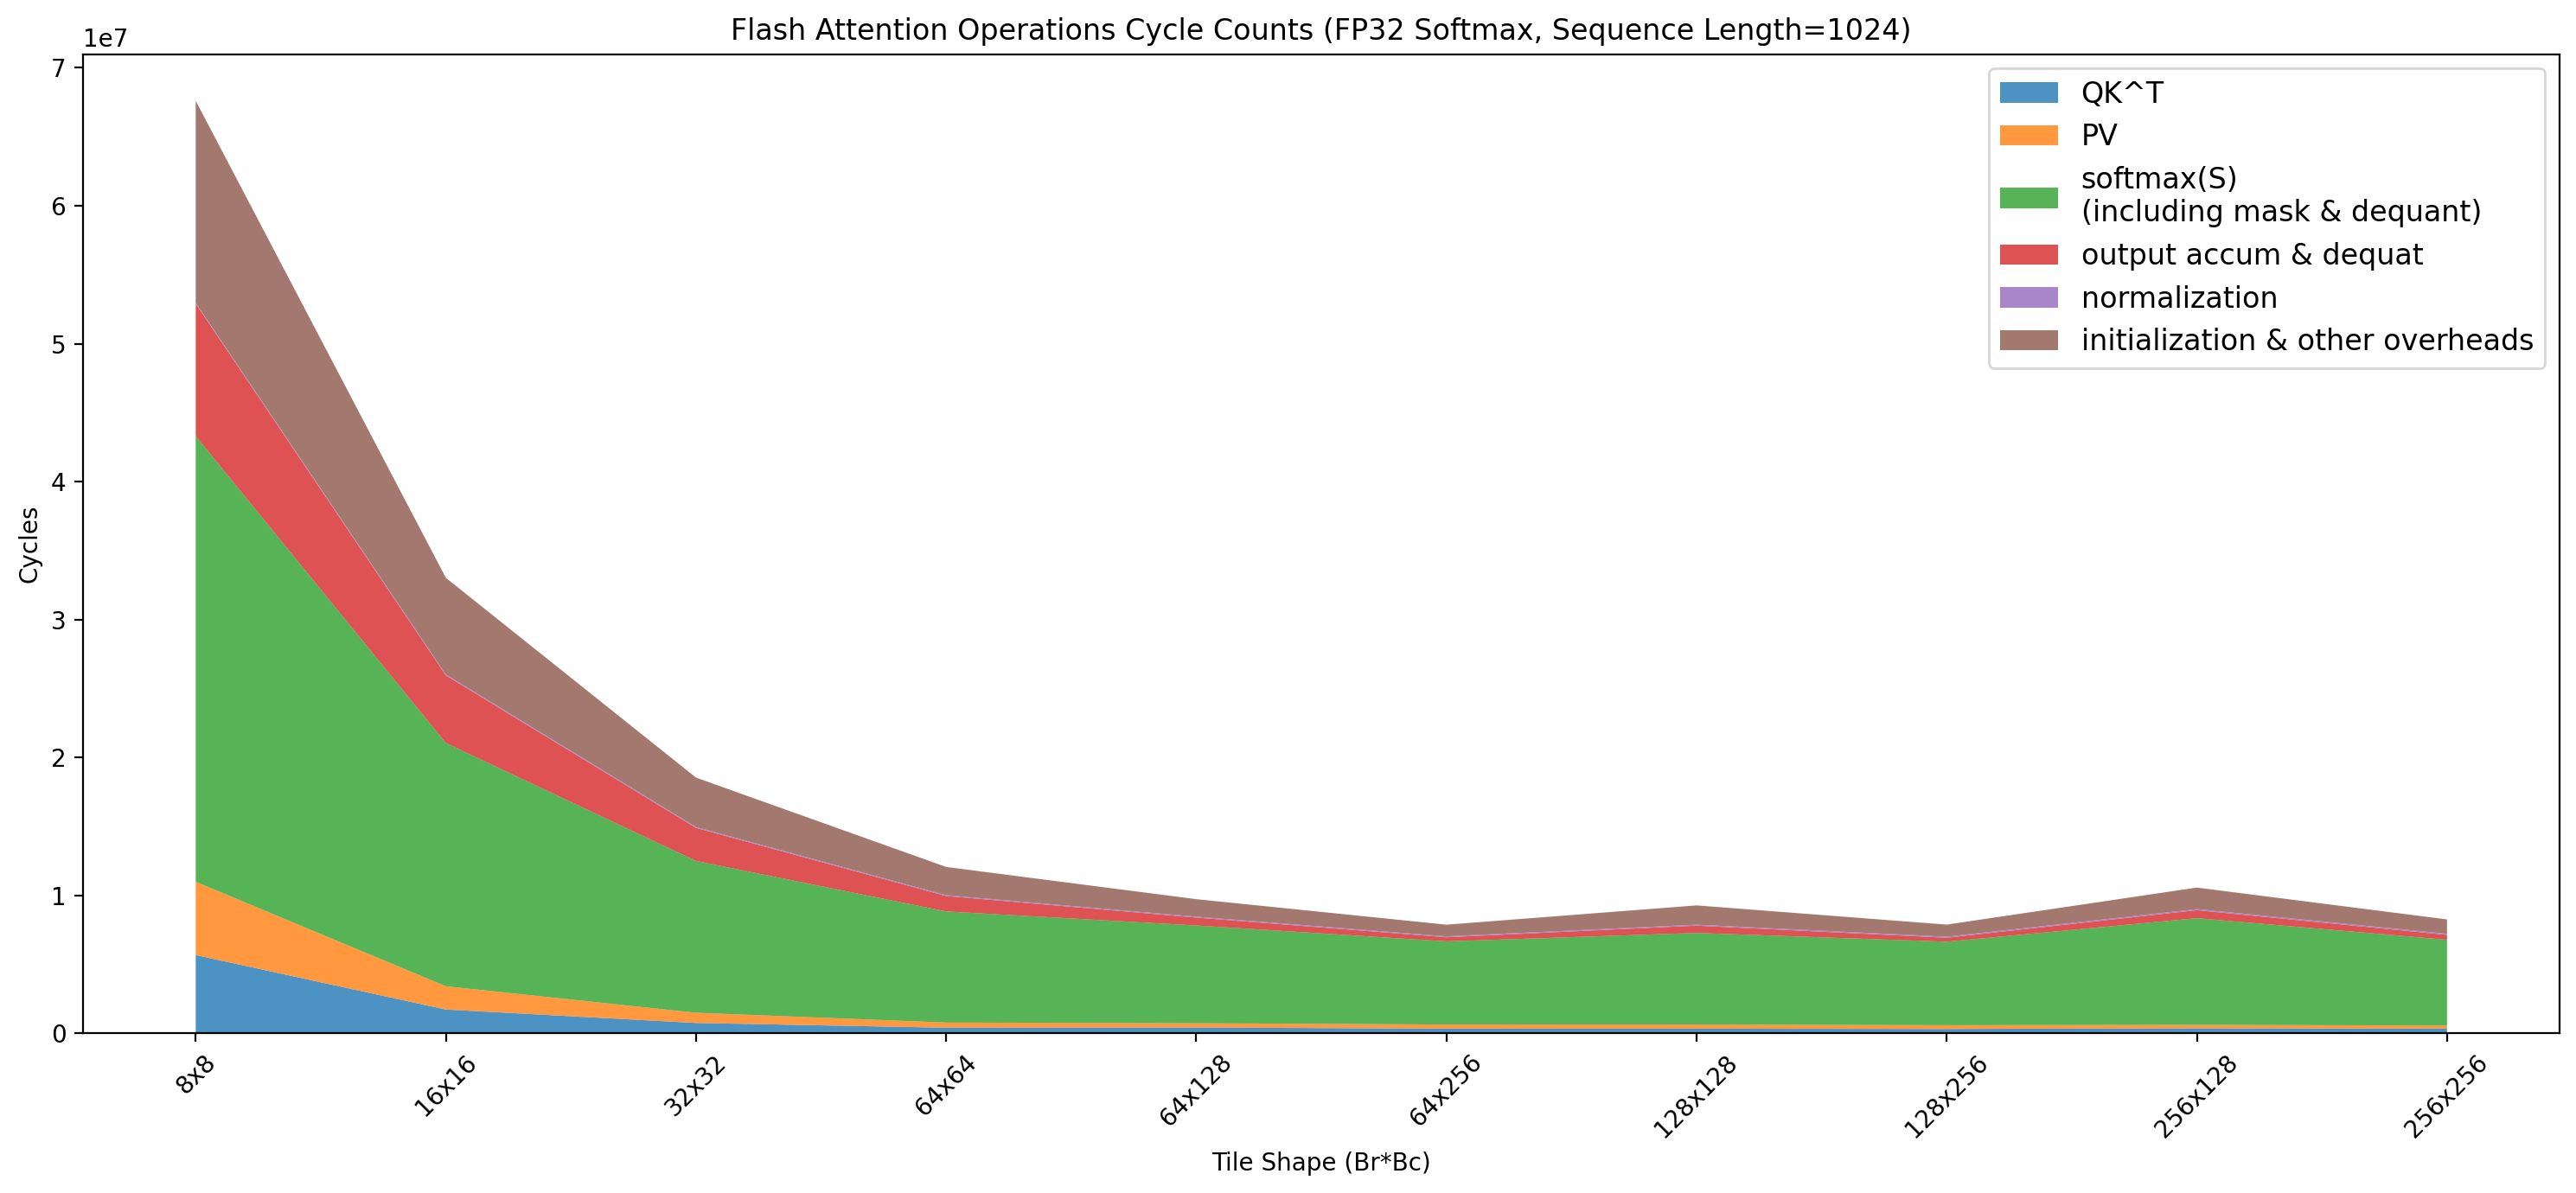

In [24]:
df_withoutTotal = df_single_head_per_tile_fp32.drop(index="TOTAL", inplace=False)
operations = df_withoutTotal.index.tolist()
tile_shapes = df_withoutTotal.columns.tolist()

plt.figure(figsize=(15, 7), dpi=200)
plt.stackplot(range(len(tile_shapes)), [df_withoutTotal.loc[op] for op in operations], labels=operations, alpha=0.8)
plt.xticks(range(len(tile_shapes)), tile_shapes, rotation=45)
plt.xlabel("Tile Shape (Br*Bc)")
plt.ylabel("Cycles")
plt.title("Flash Attention Operations Cycle Counts (FP32 Softmax, Sequence Length=1024)")
plt.legend(loc='upper right', fontsize='large')
plt.tight_layout()